# 04 · Compare

The payoff: a measured quantity against a synthesis parameter, once analyses
have written their results back as derived columns.

Run `03_analyze_batch` first.

In [1]:
from pathlib import Path

from NanoOrganizer import open_project
from NanoOrganizer.demo import demo_root

PROJECT = demo_root("DemoProject")

# attach=False: the micrographs were linked in 00 and are in the saved store.
# Re-attaching by folder convention would work here and would be the wrong
# habit — see the note at the top of 00.
wb = open_project(PROJECT, attach=False)
print(wb.summary())


DemoProject: 6 samples, 12 measurements (12 readable here, 0 not mounted).
Modalities: uvvis, tem
Root: /home/yuzhang/Repos/OrgDemo/DemoProject


## Why the columns are called `derived.uvvis_peak1_center`

`peak_fit` applies to *any* 1D curve and `particle_sizing` to any micrograph,
so each names its columns after the modality it ran on. Without that, fitting
a UV-Vis band and then a diffraction peak would put both centres in one
`derived.peak1_center` column and the second would silently win.

An analysis that can only mean one thing writes a bare name, and `prefix=` on
`batch()` overrides either way.

In [2]:
table = wb.table(all_samples=True)
cols = ["sample_id", "synthesis.conditions.temperature_C", "synthesis.batch_tag",
        "synthesis.status", "derived.uvvis_peak1_center", "derived.tem_d_mean",
        "derived.tem_n_particles"]
table[[c for c in cols if c in table.columns]]

,sample_id,synthesis.conditions.temperature_C,synthesis.batch_tag,synthesis.status,derived.uvvis_peak1_center,derived.tem_d_mean,derived.tem_n_particles
sample_id,,,,,,,
Sample000001,Sample000001,60.0,demo_batch_1,done,499.716048,8.153054,108
Sample000002,Sample000002,70.0,demo_batch_1,done,505.714693,9.714106,75
Sample000003,Sample000003,80.0,demo_batch_1,done,511.699996,11.109315,48
Sample000004,Sample000004,90.0,demo_batch_2,done,517.721673,12.228006,48
Sample000005,Sample000005,100.0,demo_batch_2,done,523.710406,13.536350,27
Sample000006,Sample000006,110.0,demo_batch_2,error,529.714464,15.328222,27


## Band position against synthesis temperature

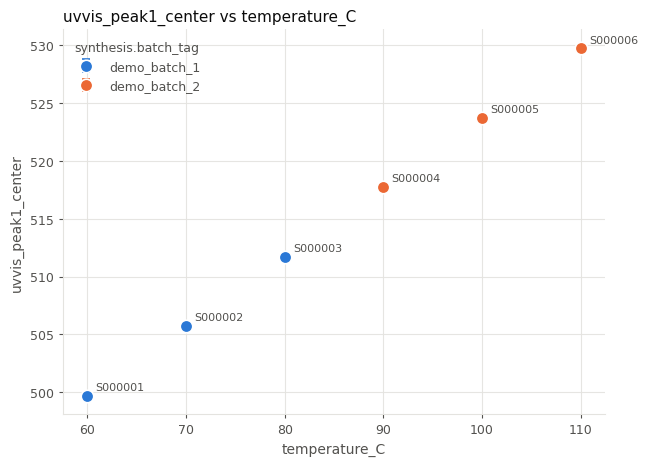

In [3]:
import matplotlib.pyplot as plt

wb.plot_compare("synthesis.conditions.temperature_C", "derived.uvvis_peak1_center",
                color_by="synthesis.batch_tag",
                yerr="derived.uvvis_peak1_center.error")
plt.show()

## Did we recover what the generator put in?

The demo data was built from a known relationship, so the fit can be checked
against the truth rather than merely looking plausible. This is the step real
data never gives you, and it is worth doing once on synthetic data to see that
the pipeline is sound.

In [4]:
from NanoOrganizer.demo import demo_truth

truth = demo_truth().set_index("sample_id")
check = table.set_index("sample_id")[["derived.uvvis_peak1_center", "derived.tem_d_mean"]].join(truth)
check["band_error_nm"] = check["derived.uvvis_peak1_center"] - check["true_band_centre_nm"]
check["size_error_nm"] = check["derived.tem_d_mean"] - check["true_diameter_nm"]
check[["true_band_centre_nm", "derived.uvvis_peak1_center", "band_error_nm",
       "true_diameter_nm", "derived.tem_d_mean", "size_error_nm"]].round(2)

,true_band_centre_nm,derived.uvvis_peak1_center,band_error_nm,true_diameter_nm,derived.tem_d_mean,size_error_nm
sample_id,,,,,,
Sample000001,500.0,499.72,-0.28,8.0,8.15,0.15
Sample000002,506.0,505.71,-0.29,9.5,9.71,0.21
Sample000003,512.0,511.70,-0.30,11.0,11.11,0.11
Sample000004,518.0,517.72,-0.28,12.5,12.23,-0.27
Sample000005,524.0,523.71,-0.29,14.0,13.54,-0.46
Sample000006,530.0,529.71,-0.29,15.5,15.33,-0.17


## Size against temperature, and against the optical band

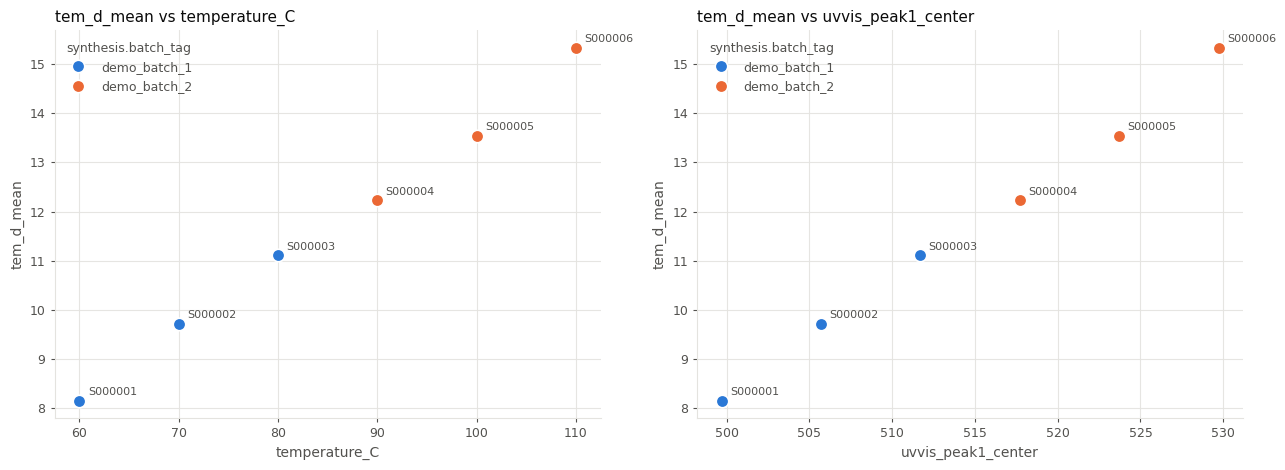

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
wb.plot_compare("synthesis.conditions.temperature_C", "derived.tem_d_mean",
                color_by="synthesis.batch_tag", ax=axes[0])
wb.plot_compare("derived.uvvis_peak1_center", "derived.tem_d_mean",
                color_by="synthesis.batch_tag", ax=axes[1])
plt.tight_layout()
plt.show()

## Watch for confounds

When points are coloured by a grouping column, compare the spread *between*
groups against the spread *within* one. If between beats within, what looks
like an effect of the x axis may just be a difference between groups — and with
one sample per group the two cannot be separated at all.

The GUI's Compare page runs this check automatically.

In [6]:
usable = table.dropna(subset=["derived.uvvis_peak1_center"])
usable.groupby("synthesis.batch_tag")["derived.uvvis_peak1_center"].agg(
    ["size", "median", "min", "max"])

,size,median,min,max
synthesis.batch_tag,,,,
demo_batch_1,3,505.714693,499.716048,511.699996
demo_batch_2,3,523.710406,517.721673,529.714464


## Export

In [7]:
keep = [c for c in table.columns
        if c == "sample_id" or c.startswith("derived.") or "conditions" in c]
table[keep].to_csv("demo_results.csv", index=False)
print("wrote demo_results.csv with", len(keep), "columns")

wrote demo_results.csv with 23 columns
